# CNN Fashion Experiment Result Aggregation

각 Fashion-MNIST CNN 실험 노트북이 저장한 JSON 결과를 모아서 성능, 파라미터 수, 학습 곡선을 비교합니다.

먼저 `00_baseline.ipynb`부터 `11_dropout_05.ipynb`까지 실행하여 결과 JSON을 저장한 뒤 이 노트북을 실행합니다.


In [17]:
import json
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULT_DIR = '/content/drive/MyDrive/CNN_fashion_results'
except ModuleNotFoundError:
    RESULT_DIR = './CNN_fashion_results'

result_paths = sorted(glob.glob(os.path.join(RESULT_DIR, '*.json')))
print('Result directory:', RESULT_DIR)
print('Result files:', len(result_paths))

results = []
for path in result_paths:
    with open(path, 'r', encoding='utf-8') as f:
        item = json.load(f)
    item['result_path'] = path
    results.append(item)

if not results:
    raise FileNotFoundError('No result JSON files found. Run each experiment notebook first.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Result directory: /content/drive/MyDrive/CNN_fashion_results
Result files: 16


## 1. 결과 요약 테이블

정확도는 보기 쉽도록 `%` 단위 컬럼도 함께 만듭니다.


In [18]:
summary_df = pd.DataFrame([
    {
        'experiment_name': r['experiment_name'],
        'params': r['parameter_count'],
        'epochs_ran': r['epochs_ran'],
        'best_val_acc_%': r['best_val_accuracy'] * 100,
        'best_val_loss': r['best_val_loss'],
        'final_val_acc_%': r['final_val_accuracy'] * 100,
        'test_acc_%': r['test_accuracy'] * 100,
        'test_loss': r['test_loss'],
        'result_path': r['result_path'],
    }
    for r in results
]).sort_values('test_acc_%', ascending=False).reset_index(drop=True)

summary_df


,experiment_name,params,epochs_ran,best_val_acc_%,best_val_loss,final_val_acc_%,test_acc_%,test_loss,result_path
0,exp15_avg_pooling,333526,14,92.183334,0.215596,92.183334,91.880000,0.236820,/content/drive/MyDrive/CNN_fashion_results/exp...
1,exp09_dense_256,824458,8,92.083335,0.220226,92.083335,91.700000,0.251064,/content/drive/MyDrive/CNN_fashion_results/exp...
2,exp08_dense_64,220234,11,92.133331,0.230386,91.983336,91.630000,0.248996,/content/drive/MyDrive/CNN_fashion_results/exp...
3,exp00_baseline,333526,9,91.991669,0.225491,91.908336,91.600001,0.248806,/content/drive/MyDrive/CNN_fashion_results/exp...
4,exp13_earlystop_patience4,333526,11,92.091668,0.225491,91.908336,91.600001,0.248806,/content/drive/MyDrive/CNN_fashion_results/exp...
5,exp14_earlystop_patience1,333526,8,91.991669,0.225491,91.908336,91.600001,0.248806,/content/drive/MyDrive/CNN_fashion_results/exp...
6,exp10_dropout_02,333526,8,92.049998,0.232311,91.933334,91.339999,0.252436,/content/drive/MyDrive/CNN_fashion_results/exp...
7,exp07_conv_3_layers,208982,9,91.775000,0.238776,91.775000,91.339999,0.252071,/content/drive/MyDrive/CNN_fashion_results/exp...
8,exp02_filters_64_128,702806,7,92.183334,0.224011,91.883332,91.180003,0.245485,/content/drive/MyDrive/CNN_fashion_results/exp...
9,exp01_filters_16_32,162710,10,91.949999,0.225266,91.683334,91.149998,0.253537,/content/drive/MyDrive/CNN_fashion_results/exp...


## 2. Test Accuracy Bar Chart

최종 테스트 정확도를 실험별로 비교합니다.


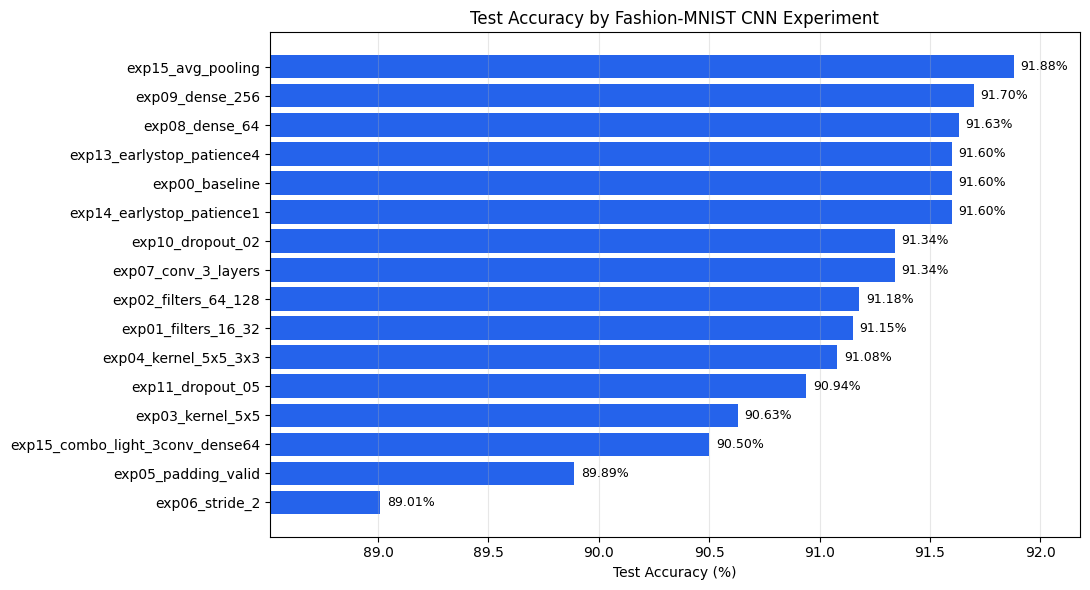

In [19]:
plot_df = summary_df.sort_values('test_acc_%', ascending=True)

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['experiment_name'], plot_df['test_acc_%'], color='#2563EB')
plt.title('Test Accuracy by Fashion-MNIST CNN Experiment')
plt.xlabel('Test Accuracy (%)')
plt.xlim(max(0, plot_df['test_acc_%'].min() - 0.5), min(100, plot_df['test_acc_%'].max() + 0.3))
plt.grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, plot_df['test_acc_%']):
    plt.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
             f'{acc:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Best Validation Accuracy Bar Chart

Early stopping 기준으로 가장 좋았던 validation accuracy를 비교합니다.


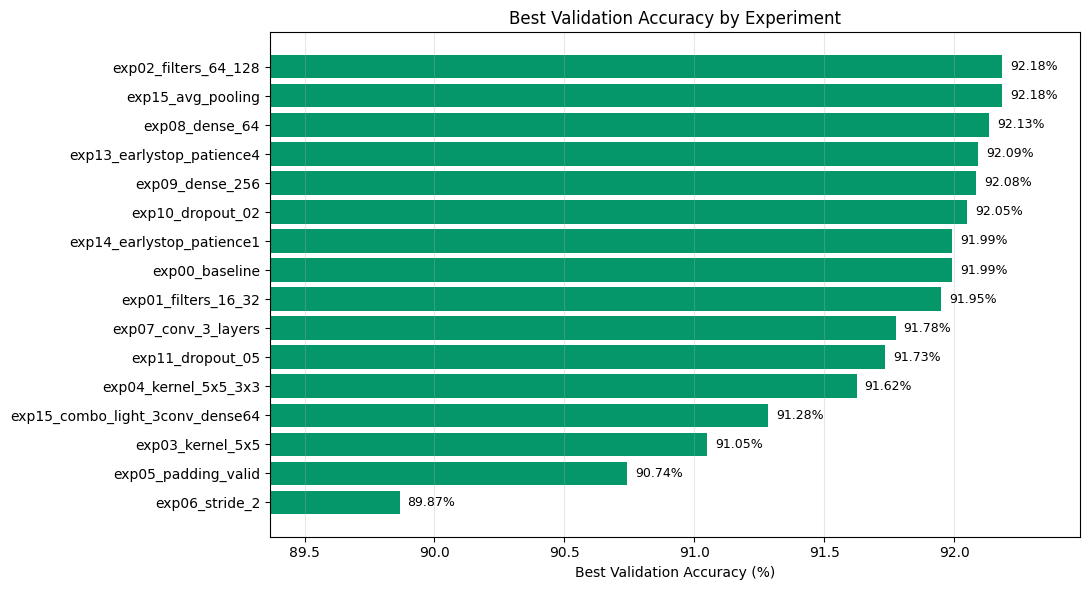

In [20]:
plot_df = summary_df.sort_values('best_val_acc_%', ascending=True)

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['experiment_name'], plot_df['best_val_acc_%'], color='#059669')
plt.title('Best Validation Accuracy by Experiment')
plt.xlabel('Best Validation Accuracy (%)')
plt.xlim(max(0, plot_df['best_val_acc_%'].min() - 0.5), min(100, plot_df['best_val_acc_%'].max() + 0.3))
plt.grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, plot_df['best_val_acc_%']):
    plt.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
             f'{acc:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 4. Epoch별 Loss Curve 비교

학습 loss와 validation loss를 함께 비교합니다. Train loss는 낮아지는데 validation loss가 상승하면 과적합 가능성이 있습니다.


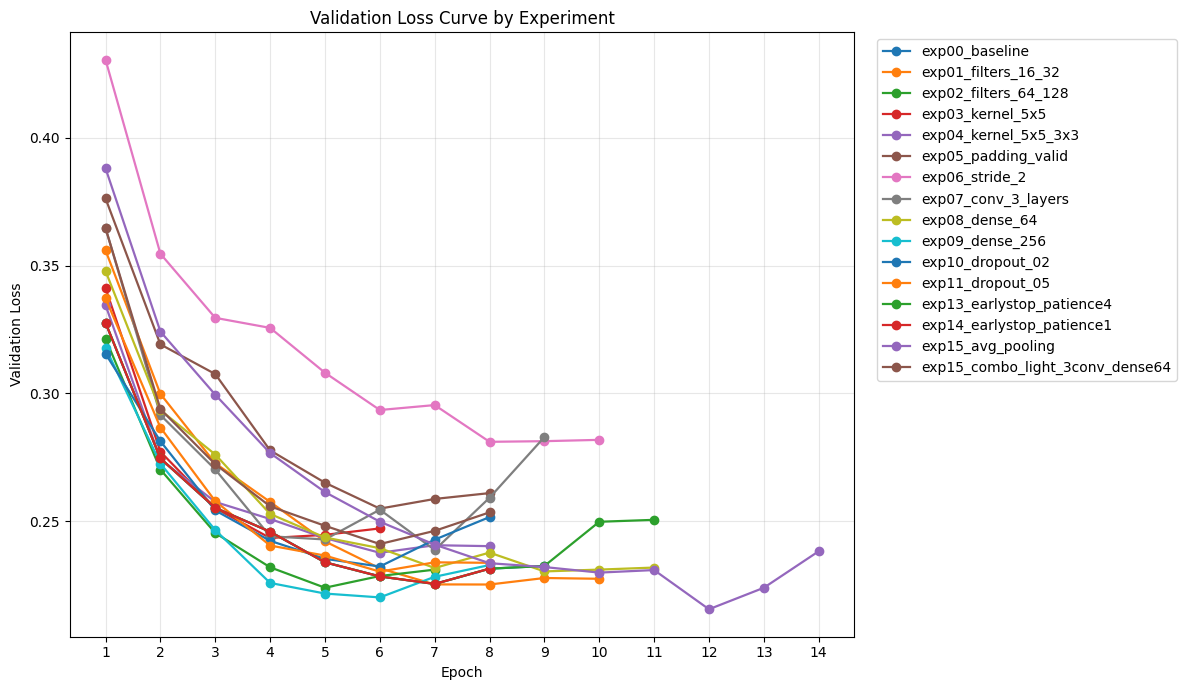

In [21]:
plt.figure(figsize=(12, 7))

for r in sorted(results, key=lambda x: x['experiment_name']):
    losses = r['val_loss_history']
    epochs = range(1, len(losses) + 1)
    plt.plot(epochs, losses, marker='o', linewidth=1.6, label=r['experiment_name'])

plt.title('Validation Loss Curve by Experiment')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.xticks(range(1, max(len(r['val_loss_history']) for r in results) + 1))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


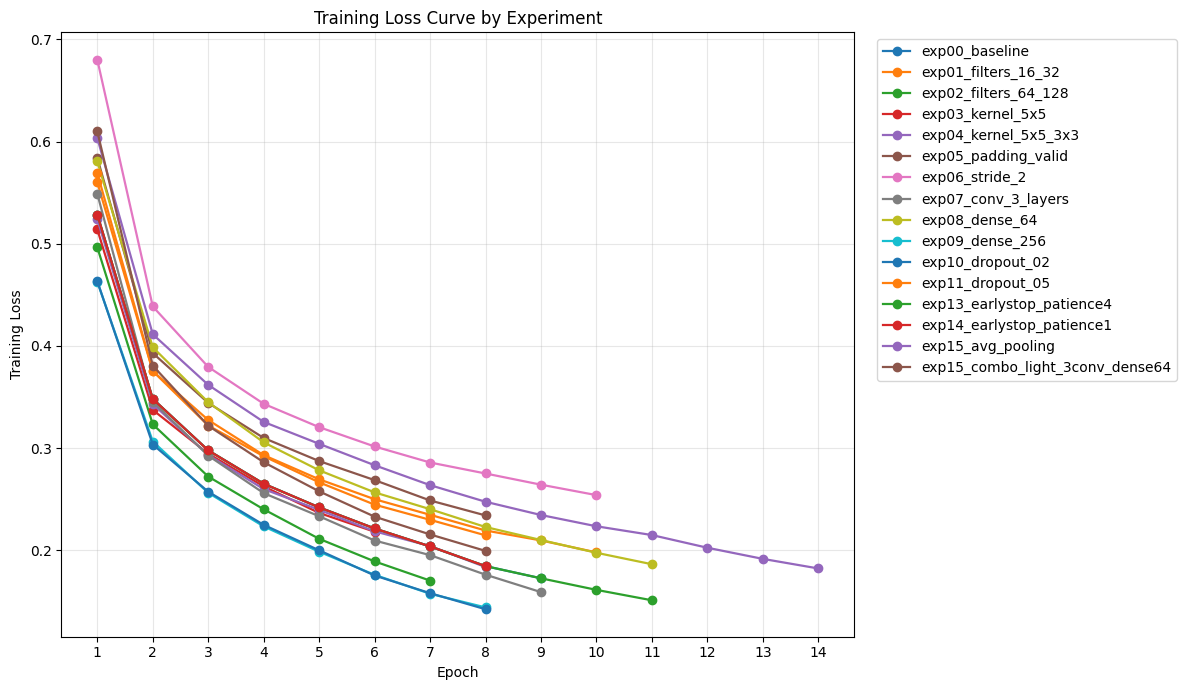

In [22]:
plt.figure(figsize=(12, 7))

for r in sorted(results, key=lambda x: x['experiment_name']):
    losses = r['train_loss_history']
    epochs = range(1, len(losses) + 1)
    plt.plot(epochs, losses, marker='o', linewidth=1.6, label=r['experiment_name'])

plt.title('Training Loss Curve by Experiment')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.xticks(range(1, max(len(r['train_loss_history']) for r in results) + 1))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Parameters vs Accuracy Scatter Plot

파라미터 수가 늘어날수록 정확도가 항상 좋아지는지 확인합니다.


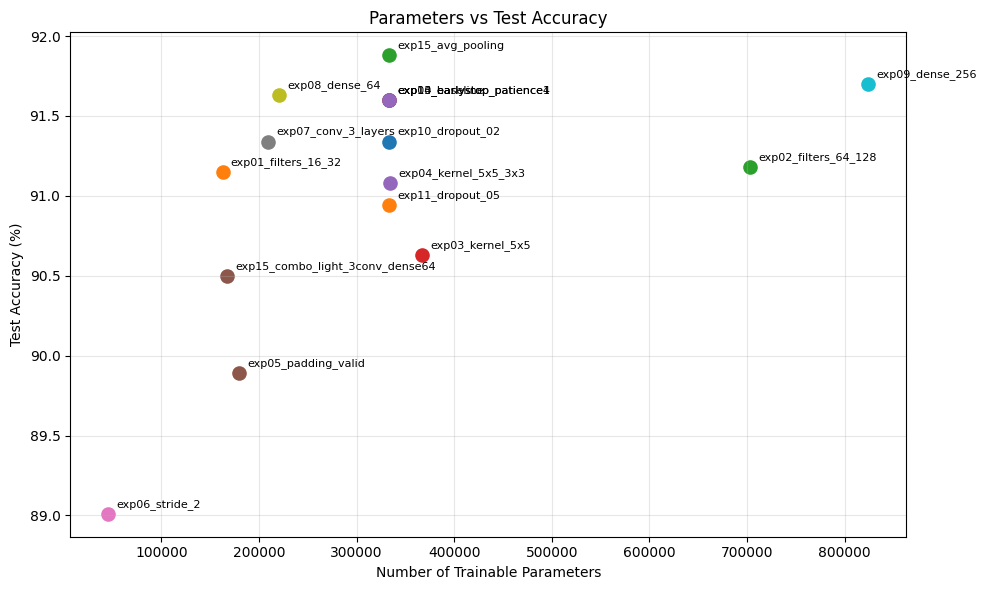

In [23]:
plt.figure(figsize=(10, 6))

for r in results:
    plt.scatter(r['parameter_count'], r['test_accuracy'] * 100, s=90)
    plt.annotate(r['experiment_name'],
                 (r['parameter_count'], r['test_accuracy'] * 100),
                 textcoords='offset points', xytext=(6, 5), fontsize=8)

plt.title('Parameters vs Test Accuracy')
plt.xlabel('Number of Trainable Parameters')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Baseline 대비 성능 변화

Baseline과 비교했을 때 각 실험의 test accuracy가 얼마나 변했는지 계산합니다.


In [24]:
baseline = next((r for r in results if r['experiment_name'] == 'exp00_baseline'), None)
if baseline is None:
    raise ValueError('Baseline result exp00_baseline was not found.')

comparison_df = summary_df.copy()
comparison_df['test_acc_delta_vs_baseline_%p'] = comparison_df['test_acc_%'] - baseline['test_accuracy'] * 100
comparison_df['param_delta_vs_baseline'] = comparison_df['params'] - baseline['parameter_count']
comparison_df = comparison_df.sort_values('test_acc_delta_vs_baseline_%p', ascending=False).reset_index(drop=True)
comparison_df[['experiment_name', 'test_acc_%', 'test_acc_delta_vs_baseline_%p', 'params', 'param_delta_vs_baseline', 'best_val_loss']]


,experiment_name,test_acc_%,test_acc_delta_vs_baseline_%p,params,param_delta_vs_baseline,best_val_loss
0,exp15_avg_pooling,91.880000,0.279999,333526,0,0.215596
1,exp09_dense_256,91.700000,0.099999,824458,490932,0.220226
2,exp08_dense_64,91.630000,0.029999,220234,-113292,0.230386
3,exp00_baseline,91.600001,0.000000,333526,0,0.225491
4,exp13_earlystop_patience4,91.600001,0.000000,333526,0,0.225491
5,exp14_earlystop_patience1,91.600001,0.000000,333526,0,0.225491
6,exp10_dropout_02,91.339999,-0.260001,333526,0,0.232311
7,exp07_conv_3_layers,91.339999,-0.260001,208982,-124544,0.238776
8,exp02_filters_64_128,91.180003,-0.419998,702806,369280,0.224011
9,exp01_filters_16_32,91.149998,-0.450003,162710,-170816,0.225266


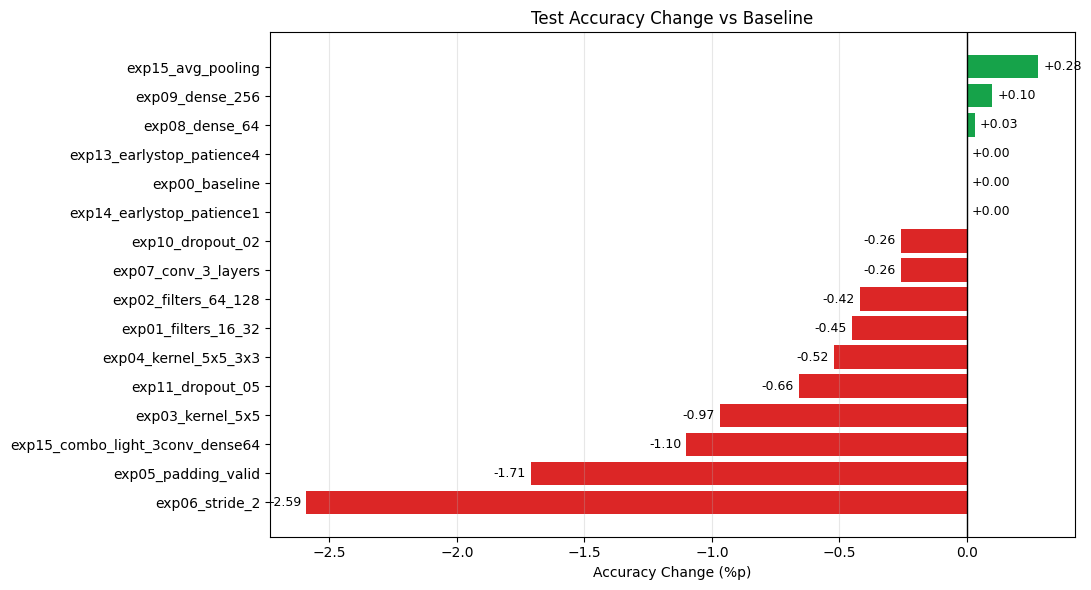

In [25]:
plot_df = comparison_df.sort_values('test_acc_delta_vs_baseline_%p', ascending=True)
colors = ['#DC2626' if x < 0 else '#16A34A' for x in plot_df['test_acc_delta_vs_baseline_%p']]

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['experiment_name'], plot_df['test_acc_delta_vs_baseline_%p'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Test Accuracy Change vs Baseline')
plt.xlabel('Accuracy Change (%p)')
plt.grid(axis='x', alpha=0.3)

for bar, delta in zip(bars, plot_df['test_acc_delta_vs_baseline_%p']):
    x = bar.get_width()
    ha = 'left' if x >= 0 else 'right'
    offset = 0.02 if x >= 0 else -0.02
    plt.text(x + offset, bar.get_y() + bar.get_height() / 2,
             f'{delta:+.2f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()


## 8. Best Validation Loss 비교

Validation loss는 모델이 얼마나 안정적으로 일반화되는지 확인하는 지표입니다. Accuracy가 비슷할 때는 loss가 낮은 모델을 더 신뢰할 수 있습니다.


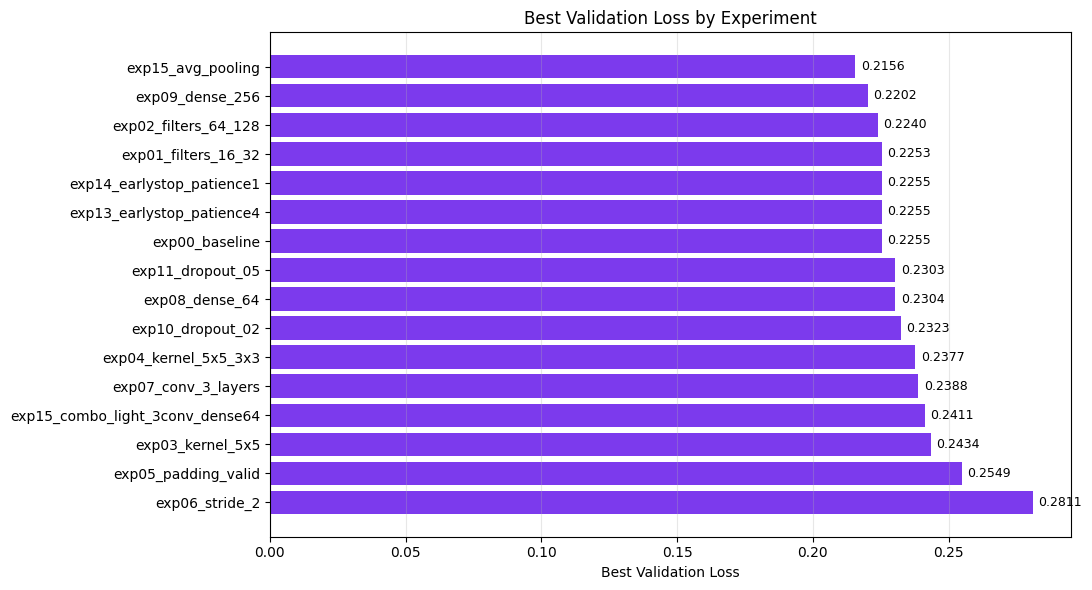

In [26]:
plot_df = summary_df.sort_values('best_val_loss', ascending=False)

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['experiment_name'], plot_df['best_val_loss'], color='#7C3AED')
plt.title('Best Validation Loss by Experiment')
plt.xlabel('Best Validation Loss')
plt.grid(axis='x', alpha=0.3)

for bar, loss in zip(bars, plot_df['best_val_loss']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{loss:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 9. Train-Val Accuracy Gap

Train accuracy와 validation accuracy의 차이를 통해 과적합 정도를 비교합니다. Gap이 클수록 학습 데이터에 더 치우쳤을 가능성이 있습니다.


In [27]:
gap_df = pd.DataFrame([
    {
        'experiment_name': r['experiment_name'],
        'final_train_acc_%': r['train_accuracy_history'][-1] * 100,
        'final_val_acc_%': r['final_val_accuracy'] * 100,
        'train_val_gap_%p': (r['train_accuracy_history'][-1] - r['final_val_accuracy']) * 100,
        'test_acc_%': r['test_accuracy'] * 100,
    }
    for r in results
]).sort_values('train_val_gap_%p', ascending=False).reset_index(drop=True)

gap_df


,experiment_name,final_train_acc_%,final_val_acc_%,train_val_gap_%p,test_acc_%
0,exp10_dropout_02,94.679165,91.933334,2.745831,91.339999
1,exp09_dense_256,94.562501,92.083335,2.479166,91.700000
2,exp07_conv_3_layers,94.058335,91.775000,2.283335,91.339999
3,exp13_earlystop_patience4,94.164586,91.908336,2.256250,91.600001
4,exp02_filters_64_128,93.639582,91.883332,1.756251,91.180003
5,exp15_combo_light_3conv_dense64,92.806250,91.066664,1.739585,90.499997
6,exp04_kernel_5x5_3x3,93.081248,91.433334,1.647913,91.079998
7,exp00_baseline,93.493748,91.908336,1.585412,91.600001
8,exp06_stride_2,90.783334,89.466667,1.316667,89.010000
9,exp14_earlystop_patience1,93.056250,91.908336,1.147914,91.600001


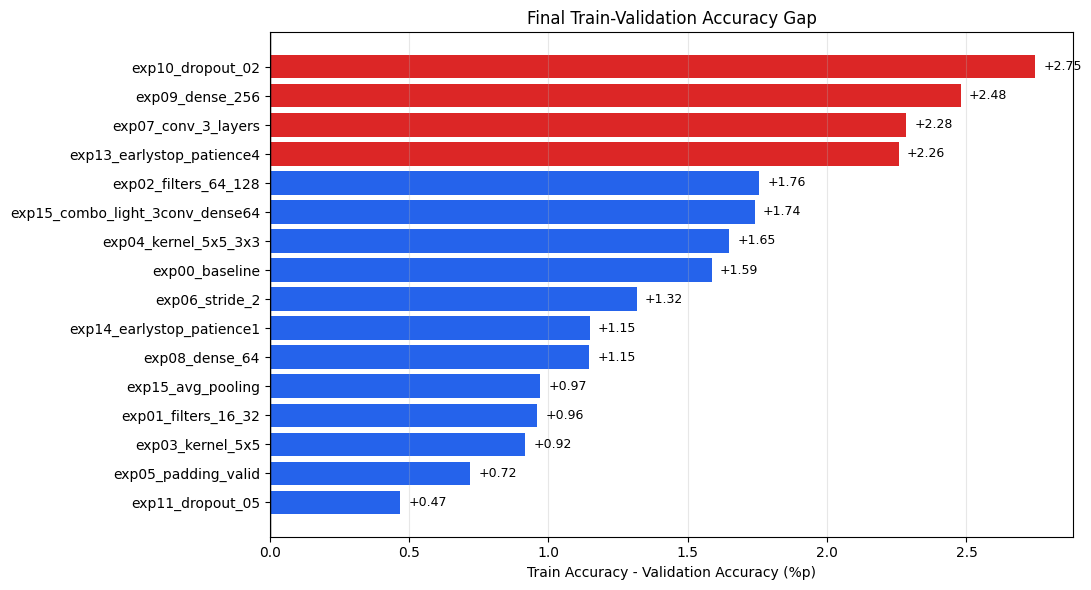

In [28]:
plot_df = gap_df.sort_values('train_val_gap_%p', ascending=True)
colors = ['#DC2626' if x > 2.0 else '#2563EB' for x in plot_df['train_val_gap_%p']]

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['experiment_name'], plot_df['train_val_gap_%p'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Final Train-Validation Accuracy Gap')
plt.xlabel('Train Accuracy - Validation Accuracy (%p)')
plt.grid(axis='x', alpha=0.3)

for bar, gap in zip(bars, plot_df['train_val_gap_%p']):
    x = bar.get_width()
    ha = 'left' if x >= 0 else 'right'
    offset = 0.03 if x >= 0 else -0.03
    plt.text(x + offset, bar.get_y() + bar.get_height() / 2,
             f'{gap:+.2f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()


## 10. 상위 모델 학습 곡선 비교

Test accuracy 기준 상위 모델과 baseline의 loss/accuracy curve를 비교합니다.


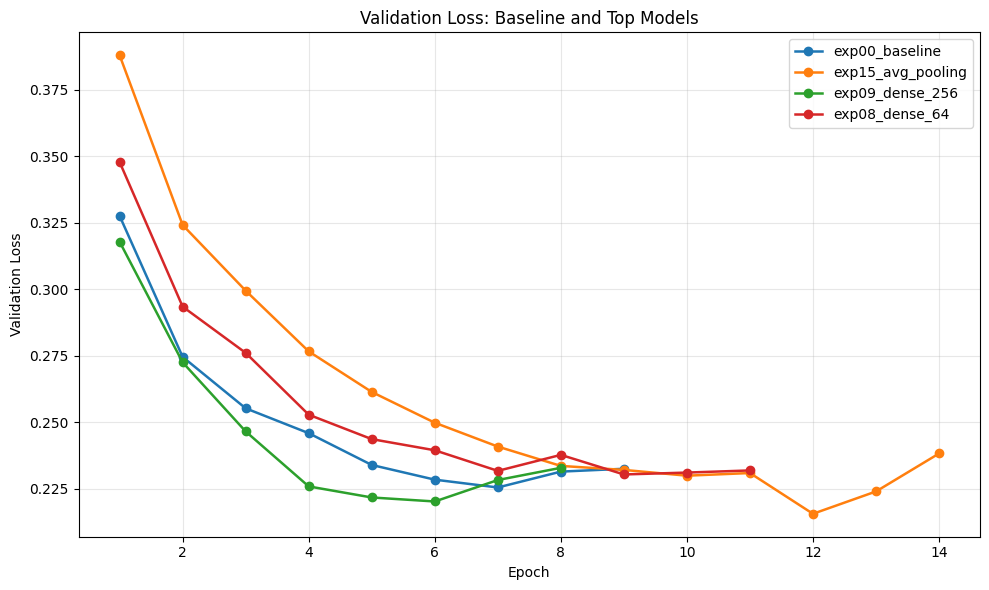

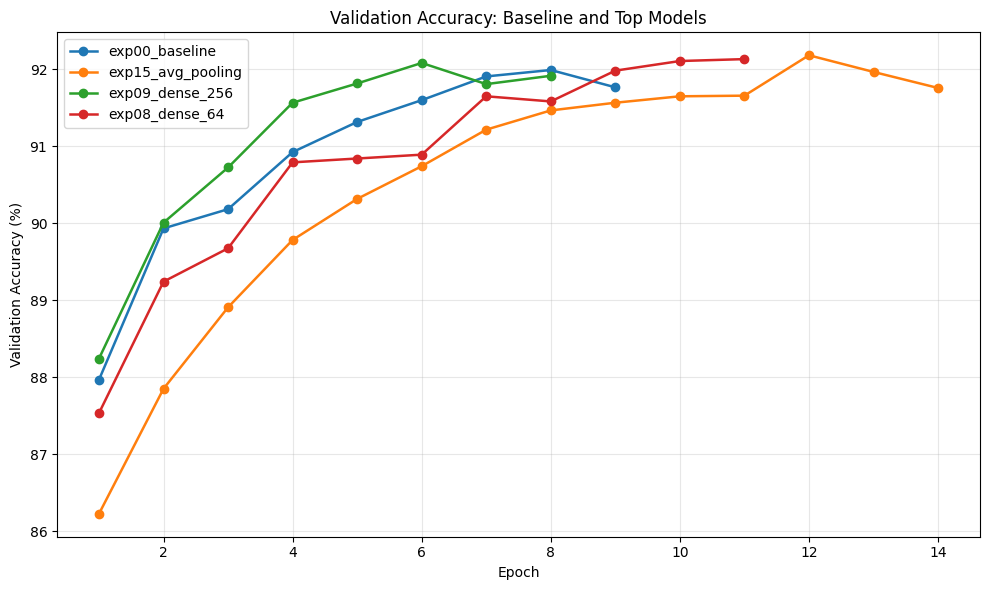

In [29]:
top_names = summary_df.head(3)['experiment_name'].tolist()
if 'exp00_baseline' not in top_names:
    top_names = ['exp00_baseline'] + top_names
selected = [r for r in results if r['experiment_name'] in top_names]
selected = sorted(selected, key=lambda r: top_names.index(r['experiment_name']))

plt.figure(figsize=(10, 6))
for r in selected:
    epochs = range(1, len(r['val_loss_history']) + 1)
    plt.plot(epochs, r['val_loss_history'], marker='o', linewidth=1.8, label=r['experiment_name'])
plt.title('Validation Loss: Baseline and Top Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for r in selected:
    epochs = range(1, len(r['val_accuracy_history']) + 1)
    plt.plot(epochs, [x * 100 for x in r['val_accuracy_history']], marker='o', linewidth=1.8, label=r['experiment_name'])
plt.title('Validation Accuracy: Baseline and Top Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 11. 모델 효율성

파라미터 10만 개당 test accuracy를 계산해 성능 대비 모델 크기를 비교합니다. 단, 이 값은 보조 지표이며 최종 판단은 accuracy/loss/gap을 함께 봅니다.


In [30]:
efficiency_df = summary_df.copy()
efficiency_df['test_acc_per_100k_params'] = efficiency_df['test_acc_%'] / (efficiency_df['params'] / 100_000)
efficiency_df = efficiency_df.sort_values('test_acc_per_100k_params', ascending=False).reset_index(drop=True)
efficiency_df[['experiment_name', 'params', 'test_acc_%', 'test_acc_per_100k_params']]


,experiment_name,params,test_acc_%,test_acc_per_100k_params
0,exp06_stride_2,45526,89.010000,195.514651
1,exp01_filters_16_32,162710,91.149998,56.019911
2,exp15_combo_light_3conv_dense64,167114,90.499997,54.154647
3,exp05_padding_valid,179926,89.889997,49.959426
4,exp07_conv_3_layers,208982,91.339999,43.707113
5,exp08_dense_64,220234,91.630000,41.605747
6,exp15_avg_pooling,333526,91.880000,27.548077
7,exp00_baseline,333526,91.600001,27.464126
8,exp13_earlystop_patience4,333526,91.600001,27.464126
9,exp14_earlystop_patience1,333526,91.600001,27.464126


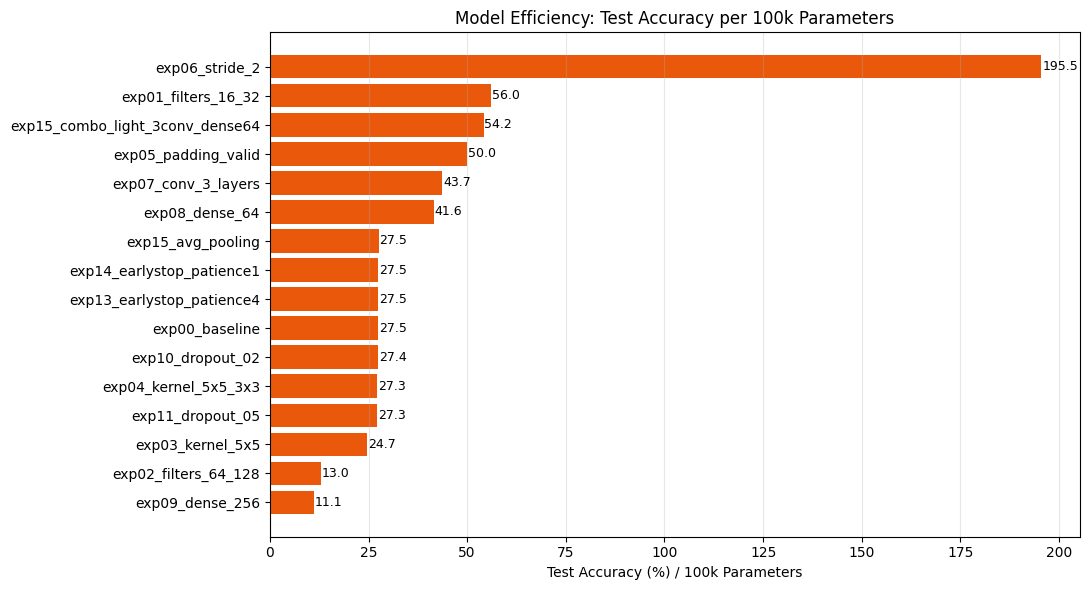

In [31]:
plot_df = efficiency_df.sort_values('test_acc_per_100k_params', ascending=True)

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['experiment_name'], plot_df['test_acc_per_100k_params'], color='#EA580C')
plt.title('Model Efficiency: Test Accuracy per 100k Parameters')
plt.xlabel('Test Accuracy (%) / 100k Parameters')
plt.grid(axis='x', alpha=0.3)

for bar, value in zip(bars, plot_df['test_acc_per_100k_params']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f'{value:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 7. CSV 저장

보고서 작성에 사용할 수 있도록 요약 결과를 CSV로 저장합니다.


In [32]:
summary_csv_path = os.path.join(RESULT_DIR, 'CNN_fashion_summary.csv')
comparison_csv_path = os.path.join(RESULT_DIR, 'CNN_fashion_comparison_vs_baseline.csv')

summary_df.to_csv(summary_csv_path, index=False, encoding='utf-8-sig')
comparison_df.to_csv(comparison_csv_path, index=False, encoding='utf-8-sig')

print('Saved:', summary_csv_path)
print('Saved:', comparison_csv_path)


Saved: /content/drive/MyDrive/CNN_fashion_results/CNN_fashion_summary.csv
Saved: /content/drive/MyDrive/CNN_fashion_results/CNN_fashion_comparison_vs_baseline.csv
